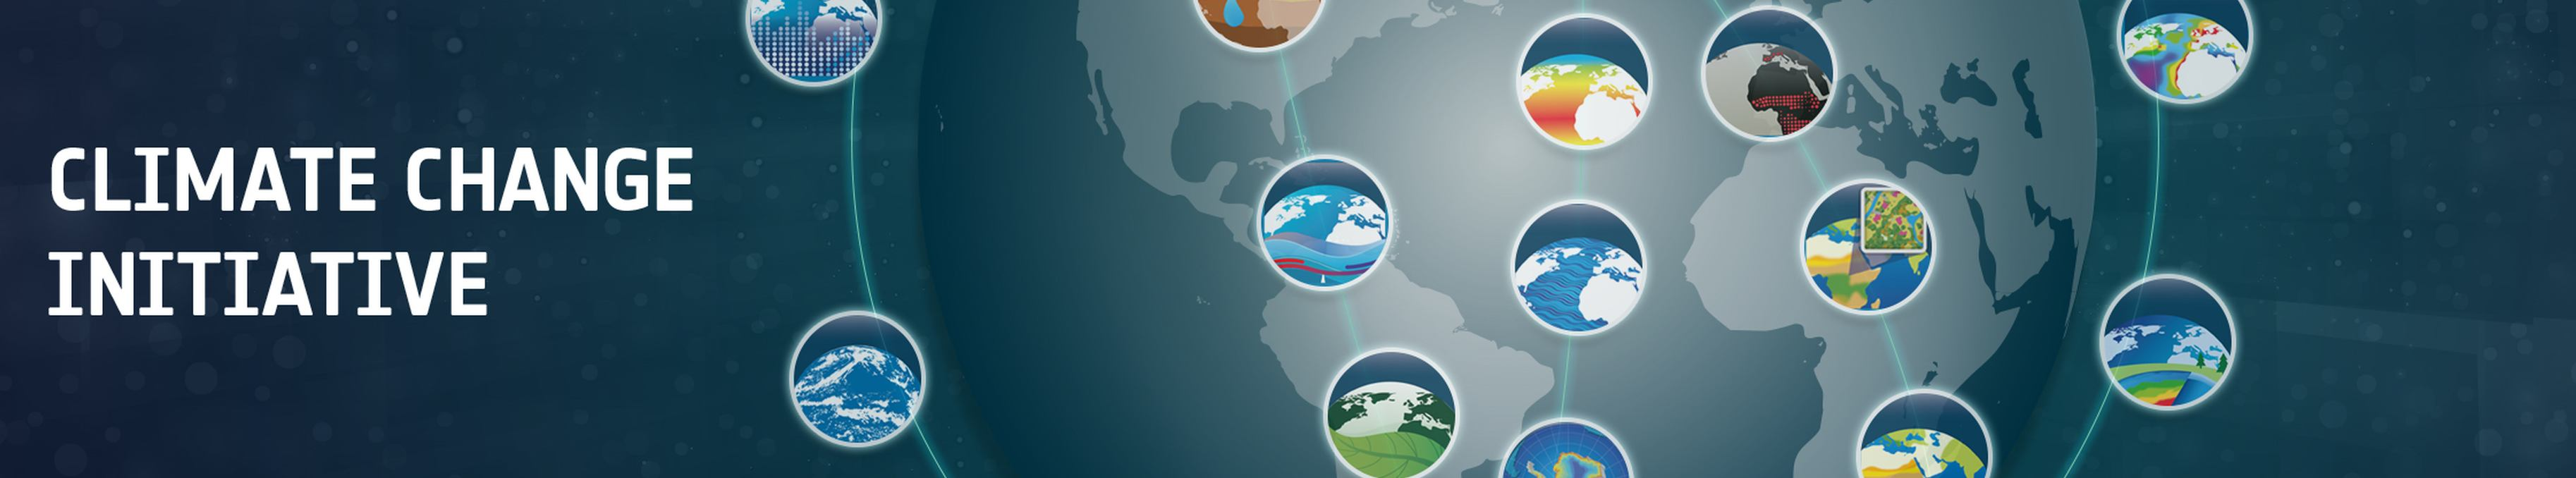

# Getting Started with Precursors for Aerosols and Ozone CCI Data

### 1. Import Necessary Packages

In this section, we import the required Python packages to work with ESA Climate Change Initiative (CCI) data. Most notably, we use the [ESA Climate Toolbox](https://esa-climate-toolbox.readthedocs.io/en/latest/) which simplifies access, manipulation, and visualization of CCI datasets in Python.

These packages allow us to:
- Access satellite-based climate data records from ESA.
- Handle geospatial and temporal dimensions efficiently.
- Visualize data with intuitive plotting tools.

📚 For a broader introduction to the toolbox and how to install it, visit:  
🔗 [ESA CCI Climate Toolbox Quick Start](https://esa-climate-toolbox.readthedocs.io/en/latest/quick_start.html#jupyter-notebooks)  
🔗 [ESA Climate Data Toolbox Website](https://climate.esa.int/en/data/toolbox/)

In [14]:
from xcube.core.store import new_data_store
from esa_climate_toolbox.core import get_op
from esa_climate_toolbox.core import list_ecv_datasets
from esa_climate_toolbox.core import get_store
from esa_climate_toolbox.core import list_datasets
from esa_climate_toolbox.ops import plot
from esa_climate_toolbox.core import open_data           
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore") 
%matplotlib inline

### Step 2: Connect to the ESA CCI Data Store

The ESA Climate Toolbox provides direct access to the **ESA Climate Data Store**, which hosts harmonised satellite-based climate data records produced under the **ESA Climate Change Initiative (CCI)**.

In this step, we establish a connection to the data store so we can browse and open datasets. This connection allows us to access data **without having to download files manually** — a convenient way to explore and analyze large geospatial datasets in cloud-friendly formats such as **Zarr** or **Kerchunk**.

The data store includes a wide range of essential climate variables (ECVs), such as aerosols, land surface temperature, sea level, and soil moisture.

📘 Learn more about available datasets:  
🔗 [ESA Climate Data Toolbox – Quick Start Guide](https://esa-climate-toolbox.readthedocs.io/en/latest/quick_start.html#data-access)

In [2]:
cci_store = new_data_store("esa-cci")
# List all available data sets of an ECV
from esa_climate_toolbox.core import list_ecvs
list_ecvs()

['SEASTATE',
 'SOILMOISTURE',
 'BIOMASS',
 'ICESHEETS',
 'LAKES',
 'LST',
 'SNOW',
 'SEALEVEL',
 'SEASURFACESALINITY',
 'OZONE',
 'WATERVAPOUR',
 'CLOUD',
 'RD',
 'AEROSOL',
 'GHG',
 'FIRE',
 'SST',
 'VEGETATION',
 'LC',
 'PREC',
 'PERMAFROST',
 'OC',
 'SEAICE']

When listing the ECVs available in the CCI store, we see the abbreviation 'PREC' which represents the Precursors for Aerosols and Ozone. We will use this in the next step to list all datasets available.

In [3]:
list_ecv_datasets("PREC")

[('esacci.PREC.day.L3C.NH3.IASI.Metop-A.ANNI-IASI_METOPA.4-0-1r.r1',
  'esa-cci'),
 ('esacci.PREC.day.L3C.NH3.IASI.Metop-B.ANNI-IASI_METOPB.4-0-1r.r1',
  'esa-cci'),
 ('esacci.PREC.day.L3C.NH3.IASI.Metop-C.ANNI-IASI_METOPC.4-0-1r.r1',
  'esa-cci'),
 ('esacci.PREC.day.L3C.NH3.IASI.multi-platform.ANNI-IASI_MERGED.4-0-1r.r1',
  'esa-cci'),
 ('esacci.PREC.mon.L3C.HCHO.TROPOMI.Sentinel-5P.TROPOMI_S5P_BIRA-1440x2880_1M.2-0.r1',
  'esa-cci'),
 ('esacci.PREC.mon.L3C.NO2.TROPOMI.Sentinel-5P.TROPOMI_KNMI-0900x1800_1M.fv1-0.r1',
  'esa-cci'),
 ('esacci.PREC.mon.L3S.CO.multi-sensor.multi-platform.IASI_MOPITT_MERGED_LATMOS-180x360_1M.1-0.r1',
  'esa-cci')]

### Step 3: Define the Dataset ID  
To work with a specific ESA CCI dataset, we need to specify its **dataset ID**. This unique identifier tells the toolbox which variable and product we want to access.

In this example, we are using a dataset from the [Precursors for aerosols and ozone](https://climate.esa.int/en/projects/precursors-for-aerosols-and-ozone/) CCI project that provides column-averaged concentrations of e.g. ammonia (NH3) and carbon monoxide (CO). These data are derived from satellite sounders IASI A/B/C, MOPITT, TROPOMI, OMI, GOME, GOME2 A/B/C and SCIAMACHY, depending on the dataset version. The observation of precursor gases are necessary to develop emission-based scenarios for radiative forcing by tropospheric ozone and secondary aerosols, due to both anthropogenic and natural sources.

In [4]:
NH3_id = 'esacci.PREC.day.L3C.NH3.IASI.multi-platform.ANNI-IASI_MERGED.4-0-1r.r1'

### Step 4: Describe Dataset (Check Available Variables and Metadata)

Before loading the full dataset, it is helpful to **inspect the metadata** to understand its structure. This includes:

- Available variables (e.g., NH3 total column, uncertainty estimates)
- Temporal and spatial coverage
- Data format and structure

Tip: By clicking on `data_vars` and the attributes (`attrs`) of the variables, we get the full name and units of the variables. 

This step ensures we know what the dataset contains and how to work with it. It also helps confirm that the variable we want to plot or analyse is actually included.

🛠️ Tip: You can use the description to verify variable names, dimensions (e.g., `lat`, `lon`, `time`), and time coverage.

📘 More on dataset structure:  
🔗 [ESA Climate Toolbox – Data Access](https://esa-climate-toolbox.readthedocs.io/en/latest/quick_start.html#accessing-data)

In [5]:
cci_store.describe_data(NH3_id)

### Step 5: Define Region, Time Range, and Variables of Interest

Before opening the dataset, we define a few key parameters:

- **Time range**: the date(s) we want to load
- **Variables**: which data variable(s) to retrieve
- *(Optional)* **Bounding box**: spatial region of interest — here we skip it to load the global dataset

In [6]:
variables = ['nh3_total_column_ampm']  # Variable to retrieve
start_date = '2025-06-30'    # Start and end date (same for a single timestep)
end_date = '2025-06-30'
# bbox = (-10.0, 35.0, 30.0, 60.0)  # Optional: restrict to a region like Europe

### Step 6: Open the Dataset

Now we open the dataset using the selected parameters using the toolbox command `open_data`.
The ESA Climate Toolbox will download only the necessary data (e.g., variable and time range).
You can always adjust the time range or variables to explore different slices of the dataset. 

In [10]:
nh3_ds, nh3_name = open_data(NH3_id,var_names=variables,time_range=[start_date, end_date])

### Step 7: Display Dataset Structure

We print a summary of the opened dataset to inspect its structure, dimensions, variables, and metadata.  
This helps verify that the data was loaded correctly and shows what is available for analysis and visualization.
This step is useful to understand what the dataset contains before working with it further.

In [11]:
display(nh3_ds)

<xarray.Dataset> Size: 6MB
Dimensions:                (lat: 900, lon: 1800, time: 1, bnds: 2)
Coordinates:
  * lat                    (lat) float32 4kB -89.9 -89.7 -89.5 ... 89.7 89.9
  * lon                    (lon) float32 7kB -179.9 -179.7 ... 179.7 179.9
  * time                   (time) datetime64[ns] 8B 2025-06-30T12:00:00
    time_bnds              (time, bnds) datetime64[ns] 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    nh3_total_column_ampm  (time, lat, lon) float32 6MB dask.array<chunksize=(1, 900, 1800), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    title:                   esacci.PREC.day.L3C.NH3.IASI.multi-platform.ANNI...
    date_created:            2026-05-29T11:15:16.226636
    processing_level:        L3C
    time_coverage_start:     2025-06-30T00:00:00
    time_coverage_end:       2025-07-01T00:00:00
    time_coverage_duration:  P1DT0H0M0S
    history:                 [{'program': 'xcube_cci.chunkstore.CciChunkStore...

### Step 8: Visualize Results

We now create a simple map plot of the selected variable using the `plot_map` function from the toolobx.
This allows us to explore the spatial patterns of the data, in this case, the column-averaged ammonia concentration for the selected day.
For more interactive and advanced visualisations, check out the [ESA Climate Toolbox](https://climate.esa.int/en/data/toolbox/) or the [Toolbox documentation](https://esa-climate-toolbox.readthedocs.io/en/latest/quick_start.html#jupyter-notebooks).

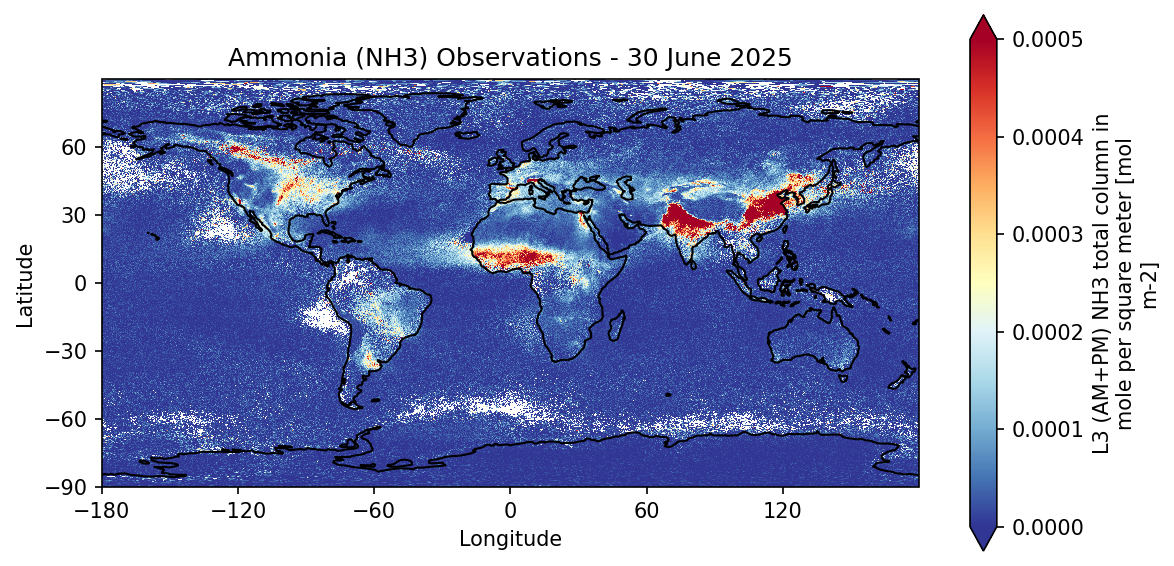

In [16]:
# Get date for the title
time_str = nh3_ds['time'].sel(time=start_date,method='nearest').dt.strftime('%d %B %Y').item()

# increasing the resolution of the figure 
plt.rcParams['figure.dpi'] = 150  

# getting the plotting operator from the toolbox
plot_map = get_op('plot_map')

plot_map(
    nh3_ds.sel(time=start_date, method='nearest'), 
    var="nh3_total_column_ampm",
    projection="PlateCarree", 
    title="Ammonia (NH3) Observations - " + time_str,
    properties=dict(cmap="RdYlBu_r", 
                    xticks=np.arange(-180, 180, 60), 
                    yticks=np.arange(-90, 90, 30),
                    vmin=0, vmax=0.0005
                    )
)
plt.gca().set_xlabel("Longitude")
plt.gca().set_ylabel("Latitude")
plt.show()